In [1]:
%pip install gensim>=4.1.2

Note: you may need to restart the kernel to use updated packages.


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from wordcloud import WordCloud
from collections import Counter
from sklearn.metrics import silhouette_score
from sentence_transformers import SentenceTransformer
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import normalize, Normalizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from gensim.parsing.preprocessing import STOPWORDS
from gensim.utils import simple_preprocess
from gensim.corpora import Dictionary, MmCorpus
import random
import warnings
import os
import services.utils as ut
import services.model as md
np.random.seed(42)
random.seed(42)

In [3]:
warnings.filterwarnings('ignore', category=UserWarning)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TRANSFORMERS_VERBOSITY'] = 'error'

In [4]:
data_df = ut.load_data('customer_support_tickets.csv')
if data_df is not None:
    print("Data loaded successfully")
print(data_df.head())

Data loaded successfully
   Ticket ID        Customer Name              Customer Email  Customer Age  \
0          1        Marisa Obrien  carrollallison@example.com            32   
1          2         Jessica Rios    clarkeashley@example.com            42   
2          3  Christopher Robbins   gonzalestracy@example.com            48   
3          4     Christina Dillon    bradleyolson@example.org            27   
4          5    Alexander Carroll     bradleymark@example.com            67   

  Customer Gender Product Purchased Date of Purchase      Ticket Type  \
0           Other        GoPro Hero       2021-03-22  Technical issue   
1          Female       LG Smart TV       2021-05-22  Technical issue   
2           Other          Dell XPS       2020-07-14  Technical issue   
3          Female  Microsoft Office       2020-11-13  Billing inquiry   
4          Female  Autodesk AutoCAD       2020-02-04  Billing inquiry   

             Ticket Subject  \
0             Product setup   

## Preprocessing

In [5]:
data_df = data_df.drop_duplicates(subset=['Ticket Description'], keep='first')
data_df.reset_index(drop=True, inplace=True)

In [6]:
data_df['text'] = data_df['Ticket Description'].fillna('')

In [7]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\{.*?\}|\[.*?\]|<.*?>|\(.*?\)', ' ', text)
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text) # remove URLs
    text = re.sub(r'[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+', ' ', text) # remove email addresses
    text = re.sub(r'[^\x00-\x7F]+', ' ', text) # remove non-ASCII characters
    text = re.sub(r'[^a-z\s]', '', text) 
    text = re.sub(r'\b[a-zA-Z]{1,2}\b', '', text)  # remove very short words
    text = re.sub(r'\s+', ' ', text).strip()
    return text

data_df['clean_text'] = data_df['text'].apply(clean_text)
data_df['clean_text'].head()

0    having issue with the please assist your billi...
1    having issue with the please assist you need c...
2    facing problem with the not turning was workin...
3    having issue with the please assist you have p...
4    having issue with the please assist note the s...
Name: clean_text, dtype: object

In [8]:
custom_words = {
    'please', 'help', 'assist', 'support', 'thanks', 'thank','soon','mentioned',
    'im', 'ive', 'us','would', 'could', 'need', 'want', 'trying',
    'tried','check', 'checked', 'make', 'made', 'get', 'getting','also',
    'use', 'using', 'used','thing', 'something', 'anything', 'everything',
    'way', 'time','issue', 'problem', 'request', 'work', 'working', 'fine',
    'available', 'recent', 'recently','facing', 'doe', 'noticed', 'happening',
    'started', 'happen','different', 'steps', 'did', 'regards','already', 'multiple',
    'last','times','followed', 'reviewed','specific', 'possible', 'related','new',
    'old','find', 'try', 'say', 'mean','name', 'email', 'price', 'one', 'unresolved',
    'add','note', 'may', 'dont', 'know','sure', 'changes', 'performed', 'properly',
    'original','like', 'similar','reported','doesnt', 'sometimes', 'acts', 'works',
    'ensure', 'desired', 'action', 'remains', 'life', 'seems', 'might', 'guide',
    'much', 'others', 'heavily', 'daily', 'task', 'affecting', 'assistance','hoping',
    'persists','didnt','option', 'perform', 'recommendation', 'information', 'official',
    'solution', 'provide', 'making', 'user', 'customer', 'item', 'device','far', 'luck',
    'contact', 'contacted', 'occurring','resolve', 'function', 'came', 'having', 'change',
    'haven', 'let', 'unable', 'able', 'afterward', 'var', 'step', 'order'
}



In [9]:
lemmatizer = WordNetLemmatizer()
final_stopwords = STOPWORDS.union(custom_words)
custom_words_lemma = set([lemmatizer.lemmatize(w.lower()) for w in final_stopwords])

def preprocess(text):
    text = str(text).lower()
    tokens = simple_preprocess(text, deacc=True)
    processed_tokens = []
    for word in tokens:
        lemma = lemmatizer.lemmatize(word)
        if (lemma not in custom_words_lemma and len(lemma) > 2 and lemma.isalnum()):
            processed_tokens.append(lemma)
    
    return " ".join(processed_tokens)

data_df['processed_text'] = data_df['clean_text'].apply(preprocess)

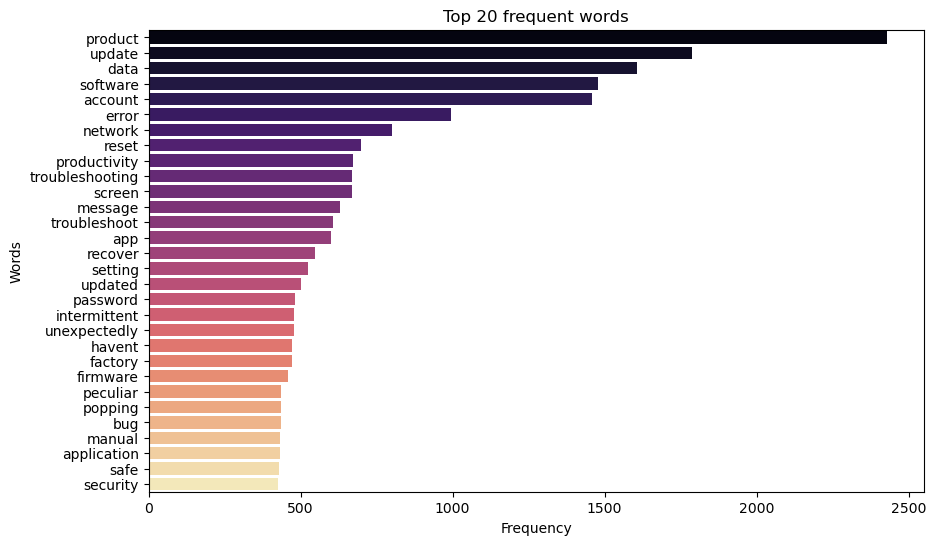

In [10]:
text_data = data_df['processed_text'].astype(str)

all_words = " ".join(text_data).lower().split()
common_words = Counter(all_words).most_common(30)

words, counts = zip(*common_words)

plt.figure(figsize=(10,6))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette='magma', legend=False)
plt.title("Top 20 frequent words")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.show()

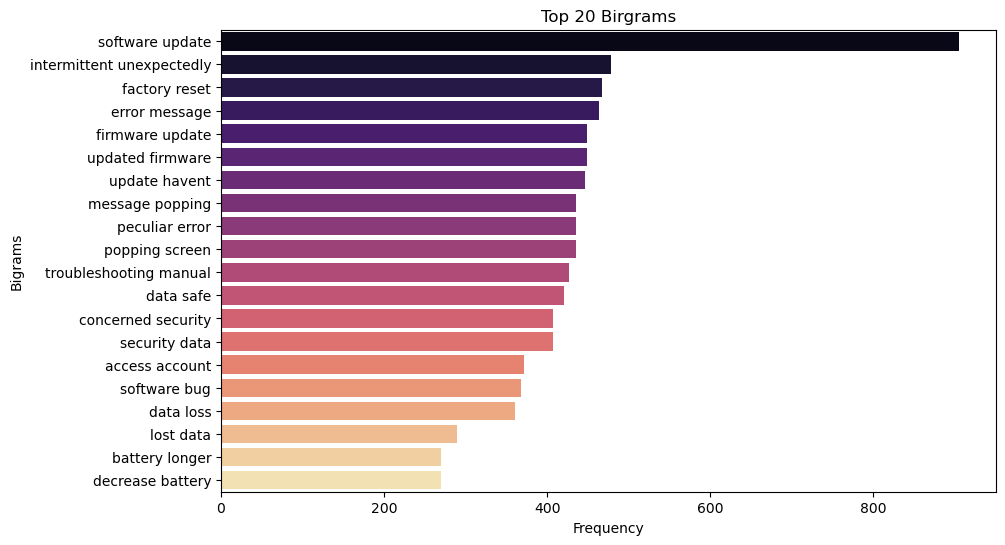

In [11]:
vectorizer = CountVectorizer(ngram_range=(2,2), stop_words='english')
x = vectorizer.fit_transform(data_df['processed_text'])
word_counts = x.sum(axis=0).A1
words = vectorizer.get_feature_names_out()
word_freq = list(zip(words, word_counts))
word_freq = sorted(word_freq, key=lambda x: x[1], reverse=True)[:20]
words, counts = zip(*word_freq)

plt.figure(figsize=(10,6))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette='magma')
plt.title("Top 20 Birgrams")
plt.xlabel("Frequency")
plt.ylabel("Bigrams")
plt.show()

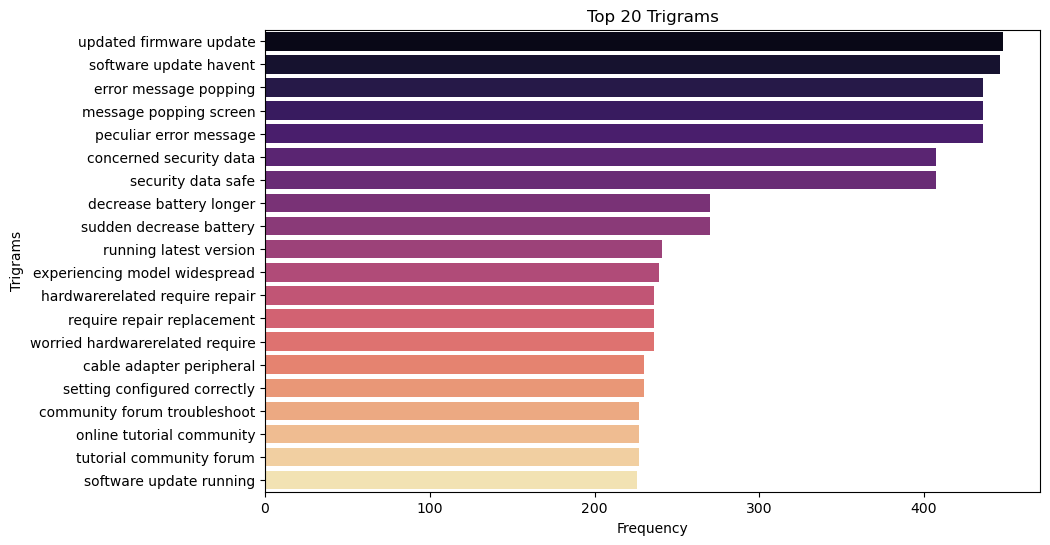

In [12]:
vectorizer = CountVectorizer(ngram_range=(3,3), stop_words='english')
x = vectorizer.fit_transform(data_df['processed_text'])
word_counts = x.sum(axis=0).A1
words = vectorizer.get_feature_names_out()
word_freq = list(zip(words, word_counts))
word_freq = sorted(word_freq, key=lambda x: x[1], reverse=True)[:20]
words, counts = zip(*word_freq)
plt.figure(figsize=(10,6))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette='magma', legend=False)
plt.title("Top 20 Trigrams")
plt.xlabel("Frequency")
plt.ylabel("Trigrams")
plt.show()

In [13]:
ut.save_data(data_df, 'cleaned_data.csv')

Building the pipeline

In [14]:
def nlp_cleaner(text_list):
    results = []
    for text in text_list:
        cleaned = clean_text(text) 
        processed = preprocess(cleaned)
        results.append(processed)
    return results

### TFIDF

In [15]:
tfidf = TfidfVectorizer(max_features=1000,ngram_range=(1,2),min_df=5,max_df=0.7)

X = tfidf.fit_transform(data_df['processed_text'])

In [16]:
tfidf__preprocessing_pipeline = Pipeline([
    ('cleaner', FunctionTransformer(nlp_cleaner, validate=False)),
    ('tfidf', TfidfVectorizer(max_features=1000,ngram_range=(1,2),min_df=5,max_df=0.7))
])

### Embeddings

In [17]:
def clean_for_embeddings(text):
    text = text.lower()
    text = re.sub(r'\{.*?\}|\[.*?\]|<.*?>|\(.*?\)', ' ', text)
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text) # remove URLs
    text = re.sub(r'[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+', ' ', text) # remove email addresses
    text = re.sub(r'[^\x00-\x7F]+', ' ', text) # remove non-ASCII characters
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [18]:
data_df['embedding_text'] = data_df['text'].apply(clean_for_embeddings)

In [32]:
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [20]:
embeddings = model.encode(data_df['embedding_text'].tolist(), show_progress_bar=True)

Batches:   0%|          | 0/253 [00:00<?, ?it/s]

In [33]:
embeddings = normalize(embeddings)

In [34]:
print(cosine_similarity([embeddings[0]], [embeddings[1]]))
print(cosine_similarity([embeddings[2]], [embeddings[5]]))

[[0.440527]]
[[0.6298451]]


Building the pipeline

In [35]:
def nlp_cleaner_embeddings(text_list):
    results = []
    for text in text_list:
        cleaned = clean_for_embeddings(text) 
        results.append(cleaned)
    return results

In [36]:
embedding_preprocessing_pipeline = Pipeline([
    ('cleaner', FunctionTransformer(nlp_cleaner_embeddings, validate=False)),
    ('embeddings', md.SentenceEmbeddingTransformer(model_name='all-MiniLM-L6-v2')),
    ('normalize', Normalizer())
])

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Modelling

### Baseline Model

#### Kmeans with TFIDF

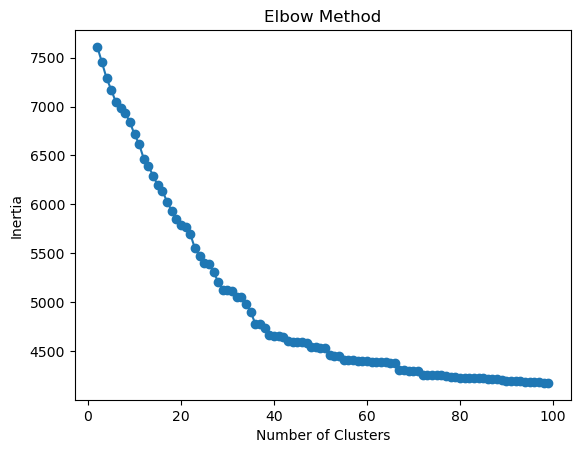

In [25]:
inertia = []

for k in range(2, 100):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X)
    inertia.append(model.inertia_)

plt.plot(range(2,100), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [26]:
k = 10

kmeansbaseline = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeansbaseline.fit_predict(X)

array([7, 2, 0, ..., 0, 2, 7], shape=(8077,), dtype=int32)

In [27]:
terms = tfidf.get_feature_names_out()

def get_top_words_per_cluster(model, X, n=20):
    centroids = model.cluster_centers_
    
    for i in range(len(centroids)):
        top_indices = centroids[i].argsort()[-n:]
        top_words = [terms[j] for j in top_indices]
        
        print(f"\nCluster {i}:")
        print(top_words)

get_top_words_per_cluster(kmeansbaseline, X)


Cluster 0:
['experiencing', 'model', 'battery longer', 'decrease battery', 'sudden decrease', 'sudden', 'decrease', 'charger', 'charger charging', 'setting configuration', 'battery', 'configuration', 'charging', 'longer', 'reset', 'setting', 'factory reset', 'factory', 'productivity', 'product']

Cluster 1:
['credential', 'regain', 'logging', 'account locked', 'account account', 'unlock', 'reset recover', 'reset', 'forgotten', 'forgotten password', 'password account', 'password reset', 'recover account', 'locked', 'login', 'account password', 'access', 'access account', 'password', 'account']

Cluster 2:
['product', 'application', 'occurs', 'consistently feature', 'consistently', 'occurs consistently', 'feature application', 'feature', 'cache data', 'data app', 'clearing cache', 'cache', 'clearing', 'loss', 'data loss', 'data', 'app', 'intermittent', 'unexpectedly', 'intermittent unexpectedly']

Cluster 3:
['application crash', 'bug application', 'bug', 'encountering software', 'encou

In [28]:
labels = kmeansbaseline.labels_
distribution = pd.Series(labels).value_counts().sort_index()
print("Cluster Distribution:")
print(distribution)

Cluster Distribution:
0    3101
1     517
2     986
3     878
4     393
5     677
6     142
7     491
8     371
9     521
Name: count, dtype: int64


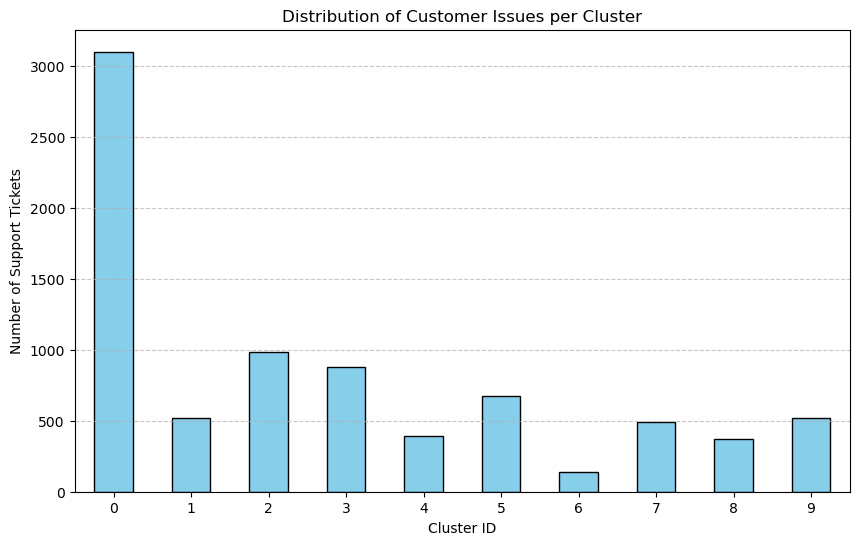

In [29]:
plt.figure(figsize=(10, 6))
distribution.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Distribution of Customer Issues per Cluster')
plt.xlabel('Cluster ID')
plt.ylabel('Number of Support Tickets')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# Sentence Embeddings + KMeans (with PCA comparison)
This section aims to compare sentence embeddings K-means without PCA (high-dimensional embeddings) and with PCA (dimensionality reduction).
## Hypothysis:
It is hypothesised that with PCA, the silhouette score will be higher than without PCA, but the cluster grouping will not perform as well as without PCA> 


In [38]:
# Clustering with no PCA
km_embed = KMeans(n_clusters=17, random_state=42, n_init=20)
data_df['cluster_embed'] = km_embed.fit_predict(embeddings)
print("KMeans clustering complete")

# Some example sentences for quality check
example_tickets = [
    "Password reset requested; I am locked out of my account.", # Account related
    "Login failed: system won't accept my sign-in details.",    # Account related
    "I've been double-billed for this month's plan.",           # Billing related
    "I need a PDF of my latest transaction receipt.",         #Billing related
    "Is it possible to include a CSV export option?"          # Requesting a new feature
]

# generate embeddings
example_embeddings = model.encode(example_tickets)
# check it works
from sklearn.metrics.pairwise import cosine_similarity
sim = cosine_similarity([example_embeddings[0]], [example_embeddings[1]])
print(f"Test Similarity score for two accounts tickets: {sim[0][0]:.4f}")
sim = cosine_similarity([example_embeddings[0]], [example_embeddings[4]])
print(f"Test Similarity score for different tickets: {sim[0][0]:.4f}")

KMeans clustering complete
Test Similarity score for two accounts tickets: 0.5435
Test Similarity score for different tickets: -0.1041


k=2 | Silhouette: 0.1181 | Inertia: 5065.16
k=3 | Silhouette: 0.1233 | Inertia: 4754.66
k=4 | Silhouette: 0.1397 | Inertia: 4525.81
k=5 | Silhouette: 0.1023 | Inertia: 4327.80
k=6 | Silhouette: 0.1220 | Inertia: 4123.61
k=7 | Silhouette: 0.1311 | Inertia: 3979.90
k=8 | Silhouette: 0.1358 | Inertia: 3864.22
k=9 | Silhouette: 0.1365 | Inertia: 3767.11
k=10 | Silhouette: 0.1459 | Inertia: 3684.76
k=11 | Silhouette: 0.1485 | Inertia: 3607.29
k=12 | Silhouette: 0.1425 | Inertia: 3525.24
k=13 | Silhouette: 0.1456 | Inertia: 3456.39
k=14 | Silhouette: 0.1496 | Inertia: 3402.38
k=15 | Silhouette: 0.1576 | Inertia: 3325.35
k=16 | Silhouette: 0.1563 | Inertia: 3269.42
k=17 | Silhouette: 0.1620 | Inertia: 3205.34
k=18 | Silhouette: 0.1535 | Inertia: 3173.32
k=19 | Silhouette: 0.1694 | Inertia: 3116.01


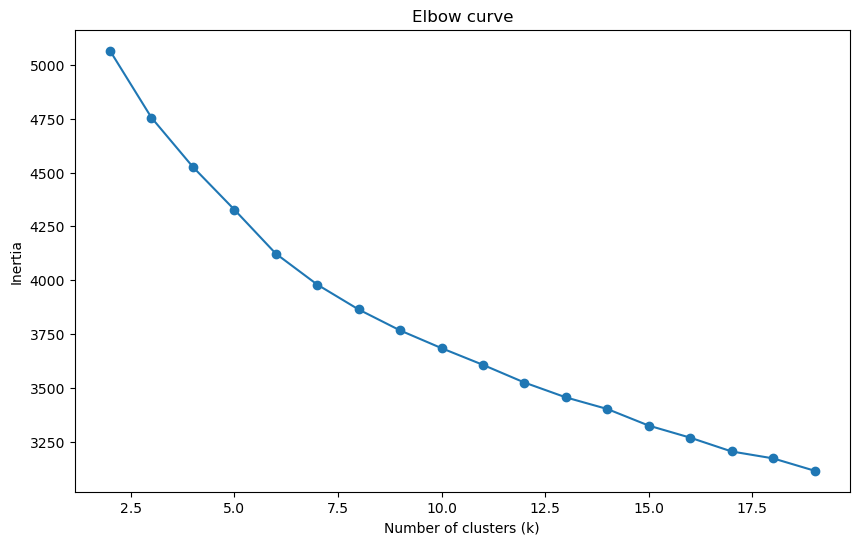

In [39]:
# convert the embedding list into 2D array for KMeans
x = embeddings
# calculate inertia for K = 2 to 20
inertia = []
silhouette_scores = []
k_range = range(2 , 20)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    cluster_labels = kmeans.fit_predict(x)
    
    # Calculate and store Silhouette Score
    s_score = silhouette_score(x, cluster_labels)
    silhouette_scores.append(s_score)
    
    # Calculate and store Inertia
    inertia.append(kmeans.inertia_)
    print(f"k={k} | Silhouette: {s_score:.4f} | Inertia: {kmeans.inertia_:.2f}")

# plot Elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow curve')
plt.show()

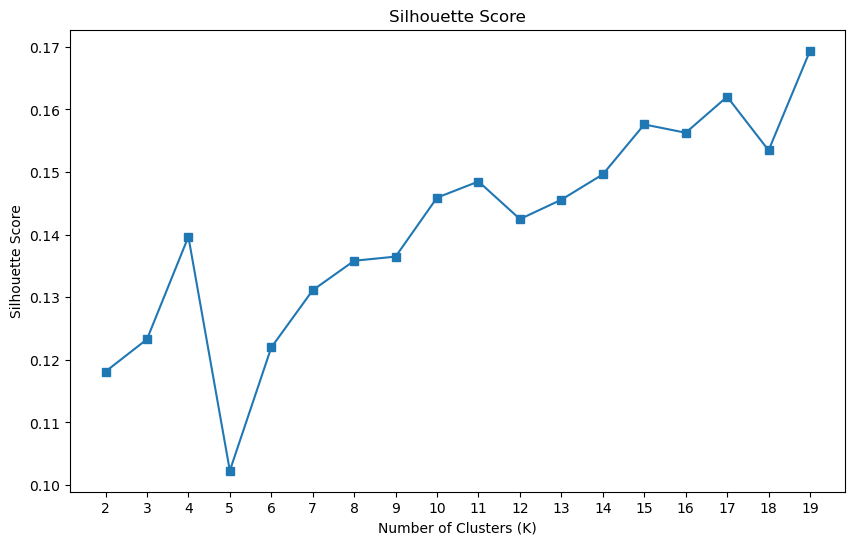

In [40]:
#plot Silhouette 
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, marker='s')
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.show()

In [41]:
from sklearn.metrics import pairwise_distances_argmin_min
closest, _ = pairwise_distances_argmin_min(km_embed.cluster_centers_, embeddings)

# 3. Print the results
for i, index in enumerate(closest):
    print(f"Cluster {i} Representative (Medoid):")
    print(f"   '{data_df.iloc[index]['embedding_text']}'")

Cluster 0 Representative (Medoid):
   'i'm having an issue with the . please assist. please provide feedback and see our products in our support channel at purchases from the product i've followed the troubleshooting steps mentioned in the user manual, but the issue persists.'
Cluster 1 Representative (Medoid):
   'i'm having an issue with the . please assist. please. don't. don't see my issue? please contact me. i'm unable to find the option to perform the desired action in the . could you please guide me through the steps?'
Cluster 2 Representative (Medoid):
   'i've encountered a data loss issue with my . all the files and documents seem to have disappeared. can you guide me on how to retrieve them? i'm sorry, but i don't have a suggestion when i'm worried that the issue might be hardware-related and might require repair or replacement.'
Cluster 3 Representative (Medoid):
   'i'm unable to access my account. it keeps displaying an 'invalid credentials' error, even though i'm using t

In [42]:
# cluster Labelling
cluster_map = {
    0: "Hardware & Device issues",
    1: "Software Errors & System Issues",
    2:" Data Loss & Hardware-Related Failures",
    3: "Account Login & Authentication Issues",
    4: "Software Bugs & System Instability",
    5: "Software Bugs & Application Crashes",
    6: "Post-Update Software Issues",
    7: "Hardware Failure / Device Not Working",
    8: "General Support & Troubleshooting Requests",
    9: "Account Security & Data Privacy",
    10: "Network Setup & Connectivity Problems",
    11: "Hardware Failures & Physical Device Issues",
    12: "Mixed / Unclear Support Requests",
    13: "Charging / Device Performance Issues",
    14: "Network Instability & Connection Drops",
    15: "Account Recovery & Login Issues",
    16: "Charging & Peripheral Device Issues"
}
# Cluster Interpretation
closest, _ = pairwise_distances_argmin_min(km_embed.cluster_centers_, embeddings)
for i, index in enumerate(closest):
    category = cluster_map.get(i, "Label Missing")
    print(f"Cluster {i} ({category}):")
    print(f"   '{data_df.iloc[index]['embedding_text']}'\n")

Cluster 0 (Hardware & Device issues):
   'i'm having an issue with the . please assist. please provide feedback and see our products in our support channel at purchases from the product i've followed the troubleshooting steps mentioned in the user manual, but the issue persists.'

Cluster 1 (Software Errors & System Issues):
   'i'm having an issue with the . please assist. please. don't. don't see my issue? please contact me. i'm unable to find the option to perform the desired action in the . could you please guide me through the steps?'

Cluster 2 ( Data Loss & Hardware-Related Failures):
   'i've encountered a data loss issue with my . all the files and documents seem to have disappeared. can you guide me on how to retrieve them? i'm sorry, but i don't have a suggestion when i'm worried that the issue might be hardware-related and might require repair or replacement.'

Cluster 3 (Account Login & Authentication Issues):
   'i'm unable to access my account. it keeps displaying an 'in

In [43]:
# Summary table
data_df['category'] = data_df['cluster_embed'].map(cluster_map)

# 3. Generate the summary table
summary_table = data_df['category'].value_counts().reset_index()
summary_table.columns = ['Category', 'Ticket Count']

# 4. Calculate Percentage
summary_table['Percentage'] = (summary_table['Ticket Count'] / len(data_df) * 100).round(2).astype(str) + '%'

# 5. Display the final result
display(summary_table)

,Category,Ticket Count,Percentage
0,General Support & Troubleshooting Requests,1269,15.71%
1,Post-Update Software Issues,1167,14.45%
2,Hardware & Device issues,1166,14.44%
3,Software Bugs & System Instability,926,11.46%
4,Data Loss & Hardware-Related Failures,470,5.82%
5,Software Bugs & Application Crashes,365,4.52%
6,Network Setup & Connectivity Problems,358,4.43%
7,Account Login & Authentication Issues,342,4.23%
8,Mixed / Unclear Support Requests,332,4.11%
9,Software Errors & System Issues,314,3.89%


| Cluster | Category                                    | Quality |
| ------- | ------------------------------------------- | ------- |
| 0       | Hardware & Device Issues                    | Good    |
| 1       | Software Errors & System Issues             | Good    |
| 2       | Data Loss & Hardware-Related Failures       | Good    |
| 3       | Account Login & Authentication Issues       | Good    |
| 4       | Software Bugs & System Instability          | Good    |
| 5       | Software Bugs & Application Crashes         | Good    |
| 6       |Post-Update Software Issues                  | Good    |
| 7       | Hardware Failure / Device Not Working       | Good    |
| 8       | General Support & Escalation Requests       | Okay    |
| 9       | Account Security & Data Privacy             | Good    |
| 10      | Network Setup & Wi-Fi Problems              | Good    |
| 11      | Hardware Failures & Physical Device Issues  | Good    |
| 12      | Mixed / Unclear Support Requests            | Bad     |
| 13      | Charging & Device Performance Issues        | Good    |
| 14      | Network Instability & Connection Drops      | Good    |
| 15      | Account Recovery & Password Reset Issues    | Good    |
| 16      | Hardware Display / Peripheral Device Issues | Good    |


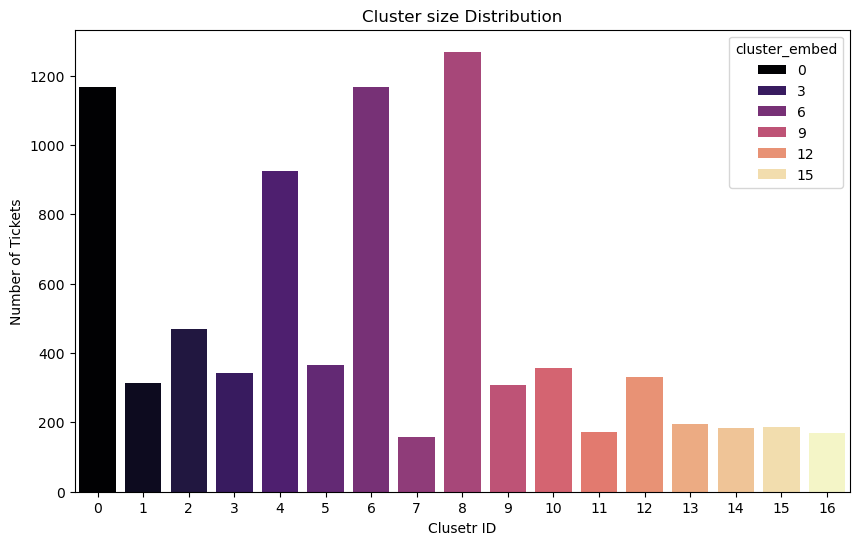

In [44]:
cluster_counts = data_df["cluster_embed"].value_counts().sort_index()

plt.figure(figsize=(10,6))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, hue=cluster_counts.index, palette="magma")
plt.xlabel("Clusetr ID")
plt.ylabel("Number of Tickets")
plt.title("Cluster size Distribution")
plt.xticks(cluster_counts.index)
plt.show()

# Sentence embedding K-means with PCA

In [45]:
# Applying PCA to Embeddings 
from sklearn.decomposition import PCA
pca = PCA(n_components=50, random_state=42)
embeddings_pca = pca.fit_transform(embeddings)

In [46]:
km_pca = KMeans(n_clusters=17, random_state=42, n_init=20)
data_df['cluster_pca'] = km_pca.fit_predict(embeddings_pca)

In [47]:
score = silhouette_score(embeddings_pca, data_df['cluster_pca'])
print(f"Silhouette (PCA): {score:.4f}")

Silhouette (PCA): 0.2122


k=2 | Silhouette: 0.1677 | Inertia: 3834.38
k=3 | Silhouette: 0.1749 | Inertia: 3524.10
k=4 | Silhouette: 0.1980 | Inertia: 3295.47
k=5 | Silhouette: 0.1403 | Inertia: 3088.26
k=6 | Silhouette: 0.1472 | Inertia: 2893.76
k=7 | Silhouette: 0.1614 | Inertia: 2748.37
k=8 | Silhouette: 0.1696 | Inertia: 2638.68
k=9 | Silhouette: 0.1674 | Inertia: 2538.59
k=10 | Silhouette: 0.1791 | Inertia: 2456.80
k=11 | Silhouette: 0.1719 | Inertia: 2375.31
k=12 | Silhouette: 0.1833 | Inertia: 2301.25
k=13 | Silhouette: 0.1882 | Inertia: 2227.71
k=14 | Silhouette: 0.1990 | Inertia: 2156.50
k=15 | Silhouette: 0.2009 | Inertia: 2100.20
k=16 | Silhouette: 0.2054 | Inertia: 2041.61
k=17 | Silhouette: 0.2122 | Inertia: 1995.72
k=18 | Silhouette: 0.2261 | Inertia: 1935.79
k=19 | Silhouette: 0.2295 | Inertia: 1878.87


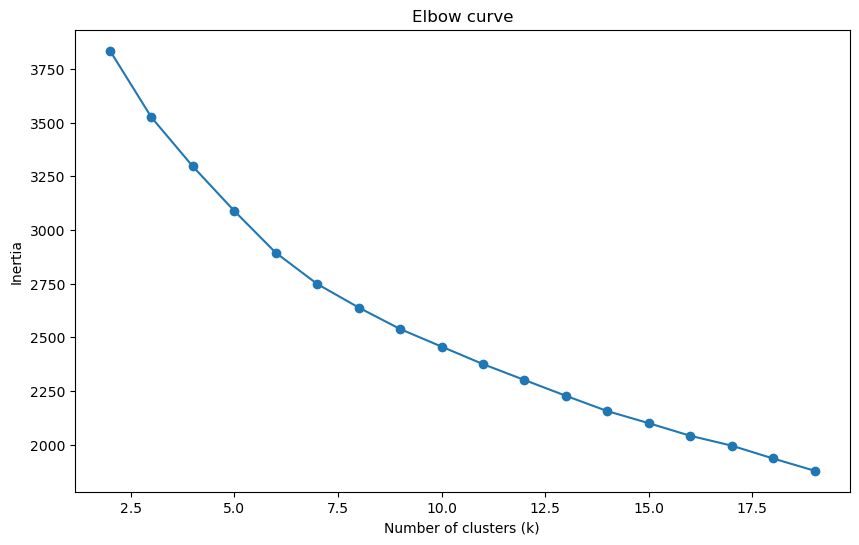

In [48]:
# convert the embedding list into 2D array for KMeans
x = embeddings_pca
# calculate inertia for K = 2 to 20
inertia = []
silhouette_scores = []
k_range = range(2 , 20)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    cluster_labels = kmeans.fit_predict(x)
    
    # Calculate and store Silhouette Score for PCA
    s_score = silhouette_score(x, cluster_labels)
    silhouette_scores.append(s_score)
    
   #Inertia
    inertia.append(kmeans.inertia_)
    print(f"k={k} | Silhouette: {s_score:.4f} | Inertia: {kmeans.inertia_:.2f}")

# plot Elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow curve')
plt.show()
    


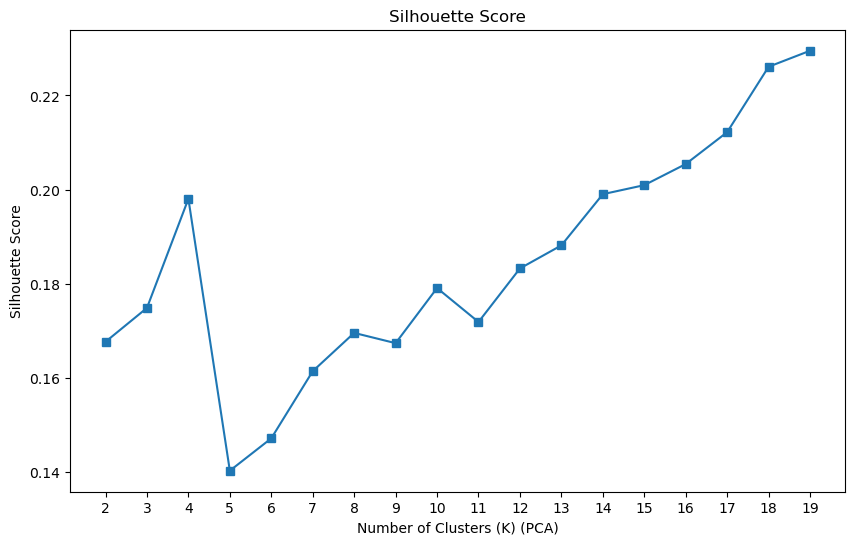

In [49]:
#plot Silhouette 
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, marker='s')
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters (K) (PCA)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.show()

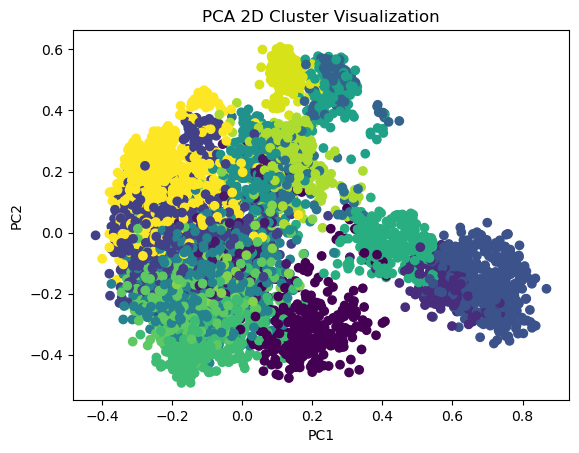

In [50]:
# 2D visualisation
pca_2d = PCA(n_components=2, random_state=42)
embeddings_2d = pca_2d.fit_transform(embeddings)

import matplotlib.pyplot as plt

plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=data_df['cluster_pca'])
plt.title("PCA 2D Cluster Visualization")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [51]:
# Cluster Interpretation
closest, _ = pairwise_distances_argmin_min(km_pca.cluster_centers_, embeddings_pca)

# Print the results
for i, index in enumerate(closest):
    print(f"Cluster {i} Representative (Medoid):")
    print(f"   '{data_df.iloc[index]['embedding_text']}'")

Cluster 0 Representative (Medoid):
   'i'm having an issue with the . please assist. this is not my product, but a way of doing things to make money and i'm so happy i have gotten through all of you (you are so i'm concerned about the security of my and would like to ensure that my data is safe.'
Cluster 1 Representative (Medoid):
   'i'm having an issue with the . please assist. please report it. this item has been out of stock. i've noticed a peculiar error message popping up on my screen. it says ' '. what does it mean?'
Cluster 2 Representative (Medoid):
   'i've forgotten my password for my account, and the password reset option is not working. how can i recover my account? your password is still active. please read this again, to help restore it. i've already contacted customer support multiple times, but the issue remains unresolved.'
Cluster 3 Representative (Medoid):
   'i'm having an issue with the . please assist. sorry about that, but i'm trying hard not to get into an old 

In [55]:
cluster_map = {
    0: "Account & Data Security Concern",
    1: "Error Messages & System issues",
    2: "Account Recovery & Password Reset Failure",
    3: "General Technical Support Request",
    4: "Data Loss & File Recovery Issue",
    5: "Wi-Fi & Network Connectivity Issue",
    6: "Hardware Fault & Device Malfunction",
    7: "Customer Support Escalation & Unresolved Ticket",
    8: "Hardware Performance & Device not working",
    9: "Network Setup & Connection Failure",
    10: "Account Login & Authentication Failure",
    11: "Navigation & UI or Feature Access Issue",
    12: "General Help Request & Mixed Support Query",
    13: "Charging & Power Issue",
    14: "Software Bug & Application Crash",
    15: "Internet Connectivity Instabilitys",
    16: "Post-Update Software Issue"
}
closest, _ = pairwise_distances_argmin_min(km_pca.cluster_centers_, embeddings_pca)
for i, index in enumerate(closest):
    category = cluster_map.get(i, "Label Missing")
    print(f"Cluster {i} ({category}):")
    print(f"   '{data_df.iloc[index]['embedding_text']}'\n")

Cluster 0 (Account & Data Security Concern):
   'i'm having an issue with the . please assist. this is not my product, but a way of doing things to make money and i'm so happy i have gotten through all of you (you are so i'm concerned about the security of my and would like to ensure that my data is safe.'

Cluster 1 (Error Messages & System issues):
   'i'm having an issue with the . please assist. please report it. this item has been out of stock. i've noticed a peculiar error message popping up on my screen. it says ' '. what does it mean?'

Cluster 2 (Account Recovery & Password Reset Failure):
   'i've forgotten my password for my account, and the password reset option is not working. how can i recover my account? your password is still active. please read this again, to help restore it. i've already contacted customer support multiple times, but the issue remains unresolved.'

Cluster 3 (General Technical Support Request):
   'i'm having an issue with the . please assist. sorry a

In [56]:
# Summary table for PCA
data_df['category'] = data_df['cluster_pca'].map(cluster_map)

# 3. Generate the summary table
summary_table = data_df['category'].value_counts().reset_index()
summary_table.columns = ['Category', 'Ticket Count']

# 4. Calculate Percentage
summary_table['Percentage'] = (summary_table['Ticket Count'] / len(data_df) * 100).round(2).astype(str) + '%'

# 5. Display the final result
display(summary_table)

,Category,Ticket Count,Percentage
0,Customer Support Escalation & Unresolved Ticket,1352,16.74%
1,General Technical Support Request,1266,15.67%
2,Post-Update Software Issue,1251,15.49%
3,General Help Request & Mixed Support Query,652,8.07%
4,Data Loss & File Recovery Issue,470,5.82%
5,Software Bug & Application Crash,371,4.59%
6,Error Messages & System issues,350,4.33%
7,Account Login & Authentication Failure,341,4.22%
8,Navigation & UI or Feature Access Issue,317,3.92%
9,Account & Data Security Concern,315,3.9%


| Cluster | Category                                    | Quality |
| ------- | ------------------------------------------- | ------- |
| 0       | Account Security & Data Privacy             | Okay    |
| 1       | Error messages & System Issues              | Good    |
| 2       | Account Recovery & Password Reset           | Good    |
| 3       | General Technical Support                   | okay    |
| 4       | Data Loss & File Recovery                   | Good    |
| 5       | Wi-Fi & Home Network Connectivity           |Excellent|
| 6       | Hardware Fault / Device Not Working         | Good    |
| 7       | Support Escalation & Unresolved Tickets     | Okay    |
| 8       | Hardware Performance issues                 | Good    |
| 9       | Network Setup & Connection Failure          | Good    |
| 10      | Account Login & Authentication              | Okay    |
| 11      | Navigation & UI / Feature Access            | Bad     |
| 12      | General Help & Mixed Support Queries        | Bad     |
| 13      | Charging & Power Issues                     | Good    |
| 14      | Software Bugs & Application Crashes         | Good    |
| 15      | Internet Connectivity & Instability         | Good    |
| 16      | Post-Update Software issues                 | Good    |


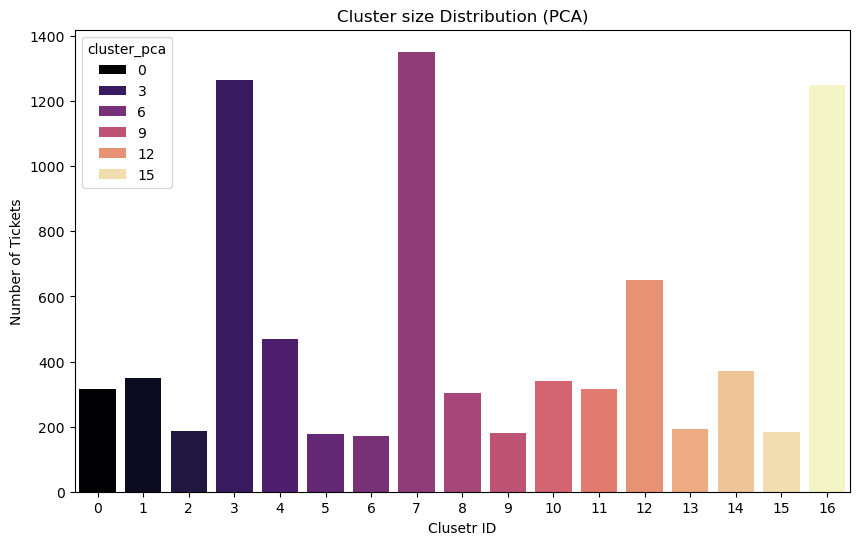

In [54]:
cluster_counts = data_df["cluster_pca"].value_counts().sort_index()

plt.figure(figsize=(10,6))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, hue=cluster_counts.index, palette="magma")
plt.xlabel("Clusetr ID")
plt.ylabel("Number of Tickets")
plt.title("Cluster size Distribution (PCA)")
plt.xticks(cluster_counts.index)
plt.show()

# Interpretation of PCA vs NO PCA clustering results
This section used sentence embeddings on customer support tickets and applied K-Means clustering. The performance was then compared with PCA and without PCA. 

### NO PCA clustering:
When high-dimensional sentence embeddings were used on K-Means, as seen clusters were generally semantically meaningful and captured ticket themes such as "account access issues", network issues, hardware failures, data concerns, and software bugs, etc. Nonetheless, some limitations were noted: some clusters had overlap, and some were noisy. These limitations made separating clusters challenging and not always visually and numerically strong. 
Overall, regardless of the limitation, some clusters work reasonably well. 

### With PCA :
K-means was rerun on the transformed feature after applying PCA. By dimensional reduction, the clusters are more structured, more consistent, and have less overlap. Moreover, some clusters that were overlapping before PCA, like hardware and network, were separated more clearly after PCA. However, the loss in fine-grained semantic details is obvious, and some clusters became overgeneralised compared to those without PCA. 

### Interpretation of Silhouette score: 
Silhouette score was used to evaluate cluster separation. With PCA, the best score was 0.2295, and without PCA, it was 0.0169, indicating better cluster separation with PCA. Nevertheless, a score of 0.23 is still considered low, indicating only moderate separation between clusters and some overlap remaining. 
These scores were expected to be seen as such data, as many categories share similar words, and it does not necessarily indicate a poor clustering. 

| Aspect             | No PCA              | PCA                      |
| ------------------ | ------------------- | ------------------------ |
| Interpretability   | Good                | Better                   |
| Cluster separation | Moderate            | Better                   |
| Noise reduction    | Lower               | Higher                   |
| Semantic detail    | Higher              | reduced                  |
| Overall structure  | Dense & overlapping | Cleaner and more compact |

In conclusion, both approaches gave informative clusters, but each had different disadvantages. performing PCA improved the overall structure of the cluster and separation, producing a more defined and cleaner but more generalised cluster. Without PCA, on the other hand, the semantic meaning was preserved, but resulted in more overlapping and less compacted clusters. 
